# 9.4.1 责任度与混合模型参数学习

## 学习目标与先修知识

推导双高斯混合的精确EM步骤，检查似然（likelihood）、标签交换和退化。

先修：9.3的条件期望（expectation）和下界，第5篇混合概率（probability），第8篇目标优化。

## 具体问题

个体测量值可能来自两个未标注的群体。先把每个个体硬分组再拟合，会把不确定的身份当成事实。能否保留这种不确定性，再更新群体均值？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE, PINK, GREEN = "#008bfb", "#ff0051", "#00a56a"

## 初步实验

对于均值−1与1、方差（variance）1、权重各一半的两个群体，计算观测（observation）−1属于第一群体的概率。

In [2]:
density1=math.exp(-(-1+1)**2/2);density2=math.exp(-(-1-1)**2/2)
print("第一分量责任度：",density1/(density1+density2))

第一分量责任度： 0.8807970779778823


## 模型假设

给定标签zᵢ∈{1,2}，读数yᵢ~N(μ[zᵢ],v)，独立个体的标签按权重w抽取；w≥0且和为1。本节共同方差（homoscedasticity）v固定为.25 U²，只学习均值与权重，样本为教学数值。标签没有额外生物学身份；相互交换权重和均值不会改变总体分布（distribution）。

## 数学解释与推导

完整数据似然为 $p(y,z\mid\theta)=\prod_i w_{z_i}N(y_i\mid\mu_{z_i},v)$，观测似然则先对每个zᵢ求和，再对个体相乘。E步使用旧参数（parameter）计算责任度（responsibility）
$$r_{ij}=\frac{w_jN(y_i\mid\mu_j,v)}{\sum_k w_kN(y_i\mid\mu_k,v)}.$$
每行和为1。它是条件概率（conditional probability），不是一个必须为0或1的分类标签。期望完整对数似然中与参数相关的部分是
$$Q(\theta\mid\theta^{old})=\sum_{ij}r_{ij}\left[\log w_j-\frac{(y_i-\mu_j)^2}{2v}\right]+C.$$
对μⱼ求导置零得到 $\mu_j^{new}=\sum_i r_{ij}y_i/N_j$，其中 $N_j=\sum_i r_{ij}$。权重在和为1的约束下由乘子法得到 $w_j^{new}=N_j/n$。若Nⱼ=0，均值在这一步目标中没有被数据约束，本节保留旧均值且权重0；这不会自动恢复死分量。

为什么精确EM使观测似然不下降？取q为旧参数下的隐标签后验（posterior），则旧参数的下界等于旧观测log似然；M步增加同一个q下的下界，新观测log似然不低于新下界。这个链式比较依赖精确E步和不降低Q的M步，不保证全局最优。

EM在这里更新参数点估计；它与“计算参数的完整后验”不同。若也自由估计分量方差，某个均值贴住单点且方差趋零时似然可能发散。本节固定方差避免这类退化，但仍会出现初始化、分量合并与标签交换。

## 核心实现

将刚才推导的关系逐步写成函数。

In [3]:
def logsumexp(values):
    top=max(values)
    return top+math.log(sum(math.exp(x-top) for x in values))


def normal_logpdf(value,mean,variance):
    return -.5*(math.log(2*math.pi*variance)+(value-mean)**2/variance)


def mixture_em(observations,weights,means,variance):
    responsibilities=[];likelihood=0.
    for y in observations:
        logs=[math.log(w)+normal_logpdf(y,m,variance) if w>0 else -math.inf for w,m in zip(weights,means)]
        z=logsumexp(logs);likelihood+=z
        responsibilities.append([math.exp(x-z) for x in logs])
    totals=[sum(row[j] for row in responsibilities) for j in range(2)]
    updated_weights=[x/len(observations) for x in totals]
    updated_means=[sum(row[j]*y for row,y in zip(responsibilities,observations))/totals[j] if totals[j]>0 else means[j] for j in range(2)]
    return responsibilities,updated_weights,updated_means,likelihood

## 对照实验

对同一组个体读数运行两种初始化。记录实际观测log似然，不能只记录Q函数；比较责任度是软分配还是近乎硬分配。

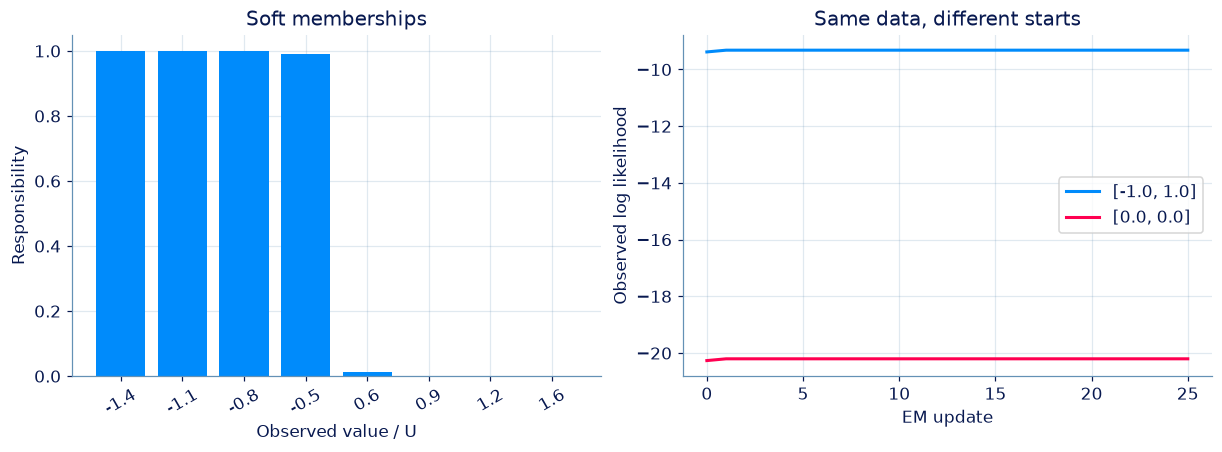

| 初始化 | 权重 | 均值 / U | 最终log似然 |
| --- | --- | --- | --- |
| [-1, 1] | [0.5003419287917753, 0.49965807120822475] | [-0.9455844134739476, 1.0719641293451359] | -9.32081 |
| [0, 0] | [0.49999999999999994, 0.49999999999999994] | [0.06250000000000001, 0.06250000000000001] | -20.2038 |

In [4]:
observed=[-1.4,-1.1,-.8,-.5,.6,.9,1.2,1.6];v=.25
fig,axes=plt.subplots(1,2,figsize=(11,4));runs=[]
for initial in [[-1.,1.],[0.,0.]]:
    weights=[.5,.5];means=initial;trace=[]
    for _ in range(25):
        responsibilities,new_weights,new_means,ll=mixture_em(observed,weights,means,v)
        trace.append(ll);weights,means=new_weights,new_means
    responsibilities,_,_,ll=mixture_em(observed,weights,means,v);trace.append(ll);runs.append((weights,means,trace))
    axes[1].plot(trace,label=str(initial))
weights,means,_=runs[0];r,_,_,_=mixture_em(observed,weights,means,v)
axes[0].bar(np.arange(len(observed)),np.array(r)[:,0],label='Component 1');axes[0].set_xticks(np.arange(len(observed)),observed,rotation=30);axes[0].set(xlabel='Observed value / U',ylabel='Responsibility',title='Soft memberships')
axes[1].set(xlabel='EM update',ylabel='Observed log likelihood',title='Same data, different starts');axes[1].legend();plt.show()
display(Markdown(show_table(['初始化','权重','均值 / U','最终log似然'],[(str(i),str(w),str(m),t[-1]) for i,(w,m,t) in zip([[-1,1],[0,0]],runs)])))

## 结果解释

完全相同的两个初始均值可能保持对称，不能自动分裂成两个群体；分开的初始化可获得不同似然。责任度描述当前模型（model）如何分配样本。比较拟合结果时，既看新数据的预测，也看分量方差：方差趋近 0 会产生退化的高似然，与稳定地解释一组数据不同。

### 独立核对

用直接密度比核对第一步责任度，用标签交换核对相同总体似然，保留零权重与极端读数的稳定计算检查。

In [5]:
r,w,m,ll=mixture_em([-1,1],[.5,.5],[-1,1],1)
expected=1/(1+math.exp(-2));np.testing.assert_allclose(r,[[expected,1-expected],[1-expected,expected]])
for _,_,trace in runs:assert min(np.diff(trace))>-1e-10
swapped=mixture_em(observed,weights[::-1],means[::-1],v)
original=mixture_em(observed,weights,means,v)
np.testing.assert_allclose(np.array(swapped[0])[:,::-1],original[0]);assert abs(swapped[-1]-original[-1])<1e-12
assert mixture_em([0,2],[1,0],[0,9],1)[2][1]==9
assert all(math.isfinite(x) for row in mixture_em([-100,100],[.5,.5],[-100,100],.1)[0] for x in row)
print('密度比、标签置换、单调性与零责任边界通过。')

密度比、标签置换、单调性与零责任边界通过。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/09-04-隐变量与参数学习/explore/)：先预测结果，再比较图形与数值。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：更新混合权重和分量均值

对固定共同方差（homoscedasticity）的双高斯混合完成一次EM更新。责任度（responsibility）不是硬分类；最后返回的是更新前似然（likelihood）。

**函数与代码模板**

```python
def solve(
    observations: list[float],
    weights: list[float],
    means: list[float],
    variance: float,
) -> tuple[list[list[float]], list[float], list[float], float]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `observations` | `list[float]` | 独立的一维个体测量值。 | U |
| `weights` | `list[float]` | 两个分量当前混合权重，非负且和为1。 | 1 |
| `means` | `list[float]` | 两个当前分量均值。 | U |
| `variance` | `float` | 两个分量共同且固定的已知方差（variance）。 | U² |

**返回值**

按以下顺序返回元组：(responsibilities, new_weights, new_means, log_likelihood)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `responsibilities` | `list[list[float]]` | 每个观测（observation）属于两个分量的当前后验（posterior）概率（probability）。 | 1 |
| `new_weights` | `list[float]` | 一次M步后的权重。 | 1 |
| `new_means` | `list[float]` | 一次M步后的均值，保持输入（input）标签顺序。 | U |
| `log_likelihood` | `float` | 更新前参数（parameter）的观测对数似然。 | 1 |

**计算规则**

r_ij∝w_j exp(−(y_i−μ_j)²/(2v))；用log-sum-exp归一化。Nj=sum_i r_ij，w′j=Nj/n，μ′j=sum_i r_ij yi/Nj；Nj=0时保留该分量原均值。不得交换标签。

**约束与边界**

- 1—100观测；均值与读数绝对值≤100；0.01≤v≤100；允许零权重但不允许权重全零。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| observations | 独立的一维个体测量值。 | [-1.0, 1.0] | U |
| weights | 两个分量当前混合权重，非负且和为1。 | [0.5, 0.5] | 1 |
| means | 两个当前分量均值。 | [-1.0, 1.0] | U |
| variance | 两个分量共同且固定的已知方差（variance）。 | 1 | U² |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
observations = [-1.0, 1.0]
weights = [0.5, 0.5]
means = [-1.0, 1.0]
variance = 1.0

result = solve(observations, weights, means, variance)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| responsibilities | 每个观测（observation）属于两个分量的当前后验（posterior）概率（probability）。 | [[0.8807970779778823, 0.11920292202211753], [0.11920292202211753, 0.8807970779778823]] | 1 |
| new_weights | 一次M步后的权重。 | [0.49999999999999994, 0.49999999999999994] | 1 |
| new_means | 一次M步后的均值，保持输入（input）标签顺序。 | [-0.7615941559557649, 0.7615941559557649] | U |
| log_likelihood | 更新前参数（parameter）的观测对数似然。 | ≈ -2.970315 | 1 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([[0.8807970779778823,
                     0.11920292202211753],
                    [0.11920292202211753,
                     0.8807970779778823]],
                   [0.49999999999999994,
                    0.49999999999999994],
                   [-0.7615941559557649,
                    0.7615941559557649],
                   -2.9703154054432908)
```

**样例解释**

观测−1对第一分量的责任度为1/(1+exp(−2))≈.880797；对称性保持权重各.5，更新均值约±.761594。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：更新混合权重和分量均值](http://127.0.0.1:8000/chapters/09-04-%E9%9A%90%E5%8F%98%E9%87%8F%E4%B8%8E%E5%8F%82%E6%95%B0%E5%AD%A6%E4%B9%A0/practice/?question=p09-mixture-update)

### 第 2 题 · 多项选择题：EM是在做哪种推断

固定模型（model）族中，用EM更新未知均值与混合权重。哪些说法正确？

- **A.** E步计算给定旧参数（parameter）的隐标签后验（posterior）。
- **B.** M步更新参数点估计。
- **C.** 这自动给出参数的完整贝叶斯后验。
- **D.** 精确E/M步骤下观测（observation）似然（likelihood）不下降，但不保证全局最优。

[作答：EM是在做哪种推断](http://127.0.0.1:8000/chapters/09-04-%E9%9A%90%E5%8F%98%E9%87%8F%E4%B8%8E%E5%8F%82%E6%95%B0%E5%AD%A6%E4%B9%A0/practice/?question=p09-em-two-targets)

### 第 3 题 · 多项选择题：权重为零的分量

当前某分量权重严格为0，所有其他密度有限正。按本题规则做EM会怎样？

- **A.** 该分量责任度（responsibility）为0，下一权重仍为0。
- **B.** 其均值可由0/0随意计算。
- **C.** 保留旧均值可避免未定义操作，但不会自动恢复该分量。
- **D.** 可以把无贡献均值当作由数据精确识别。

[作答：权重为零的分量](http://127.0.0.1:8000/chapters/09-04-%E9%9A%90%E5%8F%98%E9%87%8F%E4%B8%8E%E5%8F%82%E6%95%B0%E5%AD%A6%E4%B9%A0/practice/?question=p09-zero-component)

### 第 4 题 · 单项选择题：自由方差的危险

在高斯混合中让一个分量均值等于某观测（observation），再令其方差（variance）趋近0。哪项合理？

- **A.** 无约束似然（likelihood）可能发散；固定方差的本节例子有意避开此退化。
- **B.** 似然越大就证明机制越真实。
- **C.** EM单调性保证方差不会退化。
- **D.** 只换标签即可修复。

[作答：自由方差的危险](http://127.0.0.1:8000/chapters/09-04-%E9%9A%90%E5%8F%98%E9%87%8F%E4%B8%8E%E5%8F%82%E6%95%B0%E5%AD%A6%E4%B9%A0/practice/?question=p09-variance-collapse)

### 第 5 题 · 多项选择题：把两分量标签对换

同时对换两分量的权重和均值时，哪些量应保持？

- **A.** 总体混合密度。
- **B.** 各观测（observation）的总似然（likelihood）。
- **C.** 每列责任度（responsibility）的标签名称。
- **D.** 总体预测矩。

[作答：把两分量标签对换](http://127.0.0.1:8000/chapters/09-04-%E9%9A%90%E5%8F%98%E9%87%8F%E4%B8%8E%E5%8F%82%E6%95%B0%E5%AD%A6%E4%B9%A0/practice/?question=p09-labels)

**进一步阅读**

[Murphy，Probabilistic Machine Learning: Advanced Topics](https://probml.github.io/pml-book/book2.html)：后验近似、采样与预测检验。 [Blei 等，Variational Inference，v9](https://arxiv.org/html/1601.00670v9)：第2节的下界与坐标更新；本节数值为独立设计的教学小例子。